Importation des bibliothèques

In [3]:
import os
import random
import torch
import copy #pour copier base_model
import numpy as np
import pandas as pd 

In [4]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from models import SimpleCNN, CNN_MCdropout
from train import train_model, evaluate
from utils import mc_predict_mean_probs, generate_mc_outputs
from accuracy import accuracy_threshold, monotonic_rearrangement, isotonic_regression, monotonicity_penalty

ImportError: cannot import name 'accuracy_threshold' from 'accuracy' (d:\INRIA\MCDropout\accuracy.py)

In [ ]:
print(os.getcwd())  # donne le répertoire courant

d:\INRIA\MCDropout


Fixation du seed pour la reproductibilité

In [ ]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Si tu veux un code plus propre et réutilisable pour le seed, tu peux créer une fonction utilitaire :
def set_seed(seed):
    import random
    import torch
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Puis tu appelles simplement :
set_seed(42)

Configuration de base

Importation du modèle déjà entraîné par l'utilisateur

In [ ]:
batch_size = 128 #on peut changer la taille mais 128 est bien pour éviter underfitting ou overfitting

transform = transforms.Compose([
    transforms.ToTensor(),                   #Convertir une image en tenseur, met les valeurs des pixels entre 0 et 1
    transforms.Normalize((0.5, 0.5, 0.5),    # Moyenne RGB
                         (0.5, 0.5, 0.5))])  # Écart-type RGB; pixels deviennent centrés autour de 0

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')


Définition du CNN de base (3 couches)

Masque pour le dropout

Fonction d'entraînement et test

In [ ]:
val_ratio = 0.1  # 10% pour validation
train_size = int((1 - val_ratio) * len(trainset))
val_size   = len(trainset) - train_size

# on fixe tjrs les mêmes train et val set
train_subset, val_subset = random_split(trainset, [train_size, val_size], generator=torch.Generator().manual_seed(seed))

trainloader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader   = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)


Test manuel de plusieurs dico_layers et stockage des résultats

In [ ]:
# Liste des configurations à tester (remplace la liste par 3 variables)
dico_layers_1 = {"conv1": 0.1, "conv2": 0.1, "conv3": 0.1, "fc1": 0.2}
dico_layers_2 = {"conv1": 0.5, "fc1": 0.5}
dico_layers_3 = {"fc1": 0.8}

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_path = "best.pt"

# Vérifie si les poids existent déjà
base_model = SimpleCNN()
if os.path.exists(save_path):
    print("Chargement du modèle sauvegardé")
    base_model.load_state_dict(torch.load(save_path, map_location=device))  # même architecture que celle qui a sauvegardé
else:
    print("Pas de modèle sauvegardé, on entraîne le modèle")
    base_model = train_model(base_model, trainloader, valloader, device, epochs=20, save_path=save_path)
    base_model.load_state_dict(torch.load(save_path, map_location=device))  # recharge les meilleurs poids

base_model_mc = copy.deepcopy(base_model)

model_1 = CNN_MCdropout(base_model_mc, dico_layers=dico_layers_1, before=False).to(device)
model_2 = CNN_MCdropout(base_model_mc, dico_layers=dico_layers_2, before=True).to(device)
model_3 = CNN_MCdropout(base_model_mc, dico_layers=dico_layers_3, before=False).to(device)

# Évaluation finale du modèle sans dropout
test_loss, test_acc = evaluate(model_1, testloader, device)
print(f"Final Test Loss: {test_loss:.4f} - Test Acc: {test_acc:.4f}")

Chargement du modèle sauvegardé
Final Test Loss: 0.8186 - Test Acc: 0.7267
Final Test Loss: 0.8186 - Test Acc: 0.7267


MC Dropout prédiction

je dois garder le même batch ; mettre des seeds pour que ce soit reproductible (fonction de dropout)

In [ ]:
# Test MC Dropout sur un batch
X, Y = next(iter(testloader))
X, Y = X.to(device), Y.to(device)
probs, t1 = mc_predict_mean_probs(model, X, T=1000, verbose=True)
Y_hat = probs.argmax(1)

print("Classes vraies       :", Y.tolist())
print(f"Classes prédites    : {Y_hat.tolist()}")

acc = (Y_hat == Y).float().mean().item()
print(f"MC Dropout Test Acc: {acc:.4f}")


KeyboardInterrupt: 

Métriques

In [ ]:
user_metrics = input(
    "Quelles métriques voulez-vous calculer ?\n"
    "Options disponibles : mc_estimate, variance_predicted, variance_max, predictive_entropy_predicted, predictive_entropy_max, relative_norm\n"
    "Vous pouvez en choisir plusieurs, séparées par des virgules : ")

user_metrics = [m.strip() for m in user_metrics.split(",")]

outputs, mean_probs, metric_values, elapsed_forward, elapsed_metrics = generate_mc_outputs(
    model, X, T=1000, metrics=user_metrics, labels=Y, verbose=False)

print(f"\nListe des métriques choisies par l'utilisateur : {user_metrics}")
print(f"Temps total des forward passes : {elapsed_forward:.2f} s\n")

for metric in user_metrics:
    print(f"--- Métrique choisie : {metric} ---")
    print(f"Temps de calcul : {elapsed_metrics[metric]:.6f} s")

    metric_result = metric_values[metric]

    if metric == "mc_estimate":
        print(f"Distribution de probabilités moyennes (par échantillon) :\n{metric_result}\n")
    
    elif metric == "variance_max":
        print(f"Variance moyenne (logits) : {metric_values['variance_max_mean']:.6f}")
        print(f"Variance par échantillon :\n{metric_result}\n")

    elif metric == "variance_predicted":
        print(f"Variance softmax moyenne : {metric_values['variance_predicted_mean']:.6f}")
        print(f"Variance softmax par échantillon :\n{metric_result}\n")

    elif metric == "predictive_entropy_max":
        print(f"Entropie prédictive moyenne : {metric_values['predictive_entropy_max_mean']:.6f}")
        print(f"Entropie prédictive par échantillon :\n{metric_result}\n")

    elif metric == "predictive_entropy_predicted":
        print(f"Entropie attendue moyenne : {metric_values['predictive_entropy_predicted_mean']:.6f}")
        print(f"Entropie attendue par échantillon :\n{metric_result}\n")

    elif metric == "relative_norm":
        print(f"Norme relative moyenne : {metric_values['relative_norm_mean']:.6f}")
        print(f"Norme relative par échantillon :\n{metric_result}\n")

    else:
        print(f"Résultat brut :\n")



Liste des métriques choisies par l'utilisateur : ['variance_predicted', 'variance_max', 'predictive_entropy_predicted', 'predictive_entropy_max']
Temps total des forward passes : 14.22 s

--- Métrique choisie : variance_predicted ---
Temps de calcul : 0.000000 s
Variance softmax moyenne : 0.104815
Variance softmax par échantillon :
tensor([0.0608, 0.1979, 0.1598, 0.0695, 0.1652, 0.1800, 0.0813, 0.1606, 0.0150,
        0.1675, 0.0924, 0.1607, 0.0230, 0.2052, 0.1621, 0.0386, 0.0278, 0.0342,
        0.1703, 0.1575, 0.0512, 0.1928, 0.0058, 0.1948, 0.1540, 0.0635, 0.0575,
        0.0253, 0.0469, 0.0642, 0.1555, 0.0017, 0.0799, 0.1122, 0.1654, 0.0409,
        0.1115, 0.1419, 0.0070, 0.1559, 0.0313, 0.1173, 0.1303, 0.0675, 0.1086,
        0.1586, 0.1208, 0.0744, 0.0878, 0.0198, 0.1241, 0.0414, 0.0751, 0.1250,
        0.1208, 0.1602, 0.0691, 0.1342, 0.0457, 0.0107, 0.0326, 0.1408, 0.1746,
        0.0669, 0.0557, 0.1635, 0.1654, 0.0369, 0.1013, 0.1241, 0.0593, 0.0820,
        0.1226, 0.0037, 0

Fonctions d'accuracy

Seuil de variance_predicted

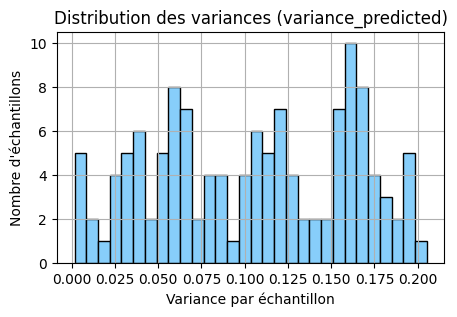

In [ ]:
variances = metric_values['variance_predicted']
if torch.is_tensor(variances):
    variances = variances.cpu().numpy()

plt.figure(figsize=(5,3))
plt.hist(variances, bins=30, color='lightskyblue', edgecolor='black')
plt.xlabel("Variance par échantillon")
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution des variances (variance_predicted)")
plt.grid(True)
plt.show()

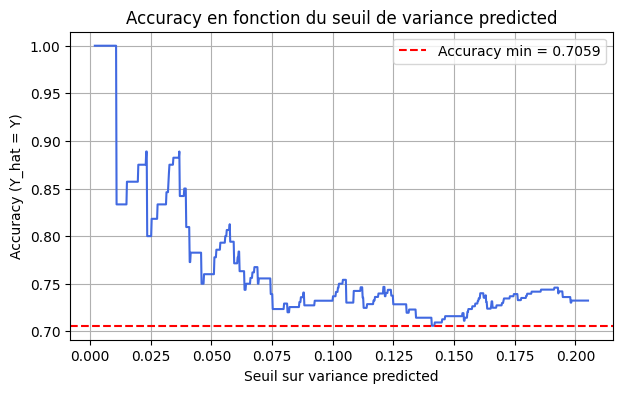

In [ ]:
thresholds_vp, accuracies_vp = accuracy_threshold(Y_hat, Y, metric_values['variance_predicted'], metric_name="variance predicted", color="royalblue")

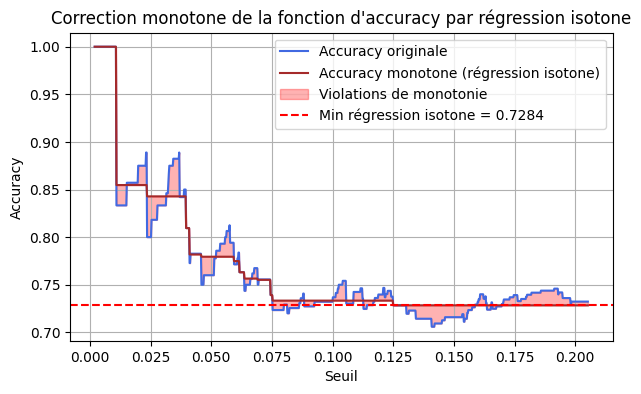

In [ ]:
iso_accuracies_vp = isotonic_regression(thresholds_vp, accuracies_vp, color='royalblue')

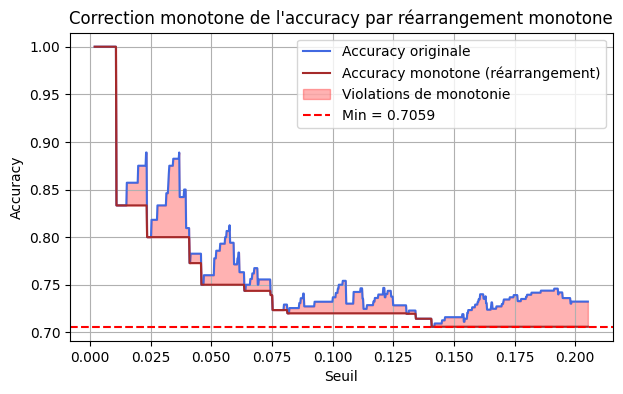

In [ ]:
rearranged_accuracies_vp = monotonic_rearrangement(accuracies_vp, thresholds_vp, accuracies_vp, color='royalblue')

In [ ]:
penalty_iso_vp = monotonicity_penalty(thresholds_vp, accuracies_vp, iso_accuracies_vp)
penalty_rearr_vp = monotonicity_penalty(thresholds_vp, accuracies_vp, rearranged_accuracies_vp)
print(f"Pénalité (aire des violations, isotone) : {penalty_iso_vp:.6f}")
print(f"Pénalité (aire des violations, réarrangement) : {penalty_rearr_vp:.6f}")

Pénalité (aire des violations, isotone) : 0.001889
Pénalité (aire des violations, réarrangement) : 0.003889


Seuil de variance_max

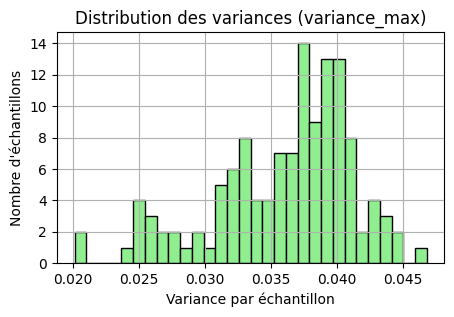

In [ ]:
variances = metric_values['variance_max']
if torch.is_tensor(variances):
    variances = variances.cpu().numpy()

plt.figure(figsize=(5,3))
plt.hist(variances, bins=30, color='lightgreen', edgecolor='black')
plt.xlabel("Variance par échantillon")
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution des variances (variance_max)")
plt.grid(True)
plt.show()

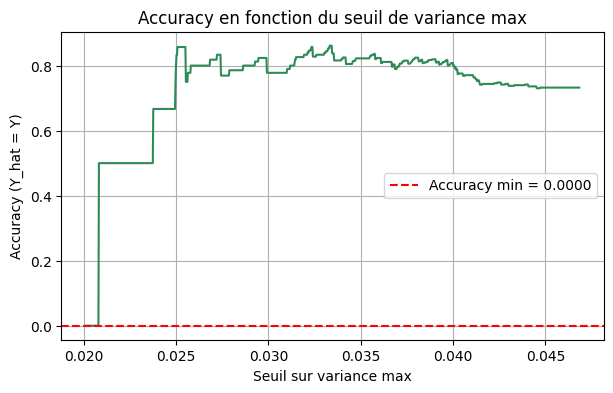

In [ ]:
thresholds_vm, accuracies_vm = accuracy_threshold(Y_hat, Y, metric_values['variance_max'], metric_name="variance max", color="seagreen")

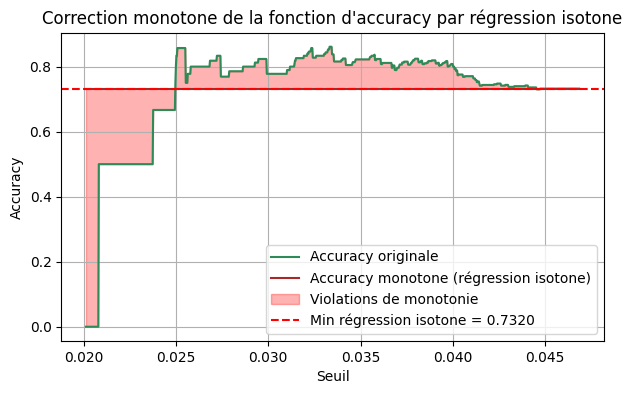

In [ ]:
iso_accuracies_vm = isotonic_regression(thresholds_vm, accuracies_vm, color='seagreen')

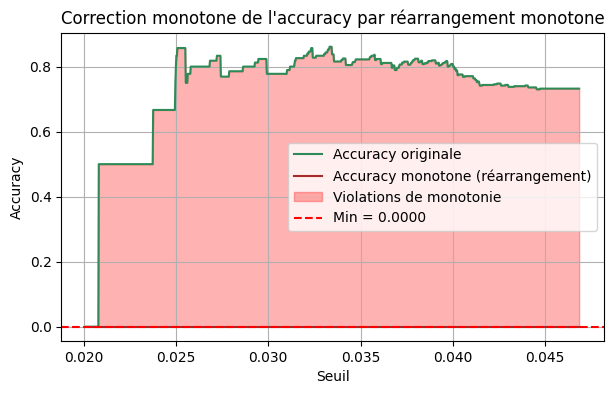

In [ ]:
rearranged_accuracies_vm = monotonic_rearrangement(accuracies_vm, thresholds_vm, accuracies_vm, color='seagreen')

In [ ]:
penalty_iso_vm = monotonicity_penalty(thresholds_vm, accuracies_vm, iso_accuracies_vm)
penalty_rearr_vm = monotonicity_penalty(thresholds_vm, accuracies_vm, rearranged_accuracies_vm)
print(f"Pénalité (aire des violations, isotone) : {penalty_iso_vm:.6f}")
print(f"Pénalité (aire des violations, réarrangement) : {penalty_rearr_vm:.6f}")

Pénalité (aire des violations, isotone) : 0.002533
Pénalité (aire des violations, réarrangement) : 0.019560


Seuil de PE_predicted

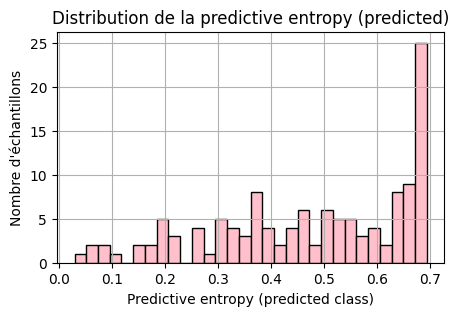

In [ ]:
entropies = metric_values['predictive_entropy_predicted']
if torch.is_tensor(entropies):
    entropies = entropies.cpu().numpy()

plt.figure(figsize=(5,3))
plt.hist(entropies, bins=30, color='pink', edgecolor='black')
plt.xlabel("Predictive entropy (predicted class)")
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution de la predictive entropy (predicted)")
plt.grid(True)
plt.show()

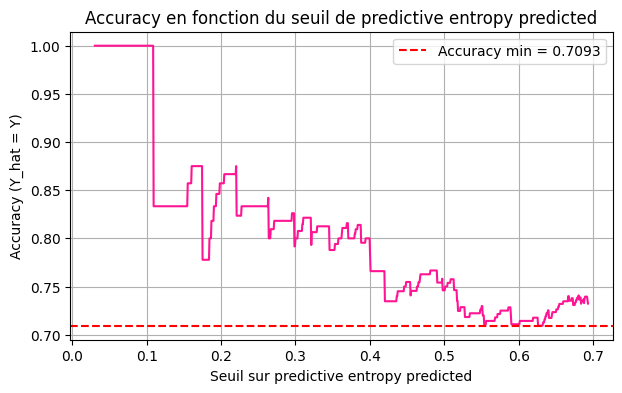

In [ ]:
thresholds_pep, accuracies_pep = accuracy_threshold(Y_hat, Y, metric_values['predictive_entropy_predicted'], metric_name="predictive entropy predicted", color="deeppink")

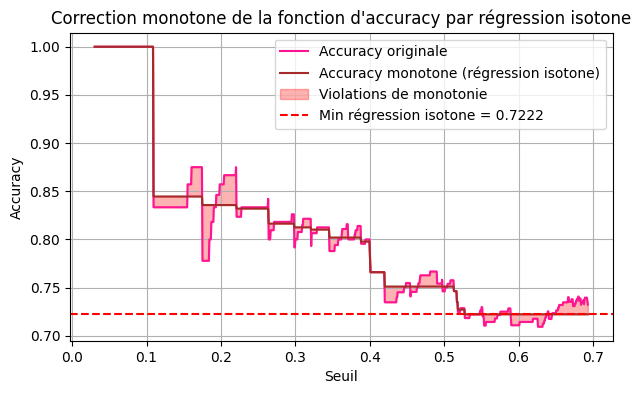

In [ ]:
iso_accuracies_pep = isotonic_regression(thresholds_pep, accuracies_pep, color='deeppink')

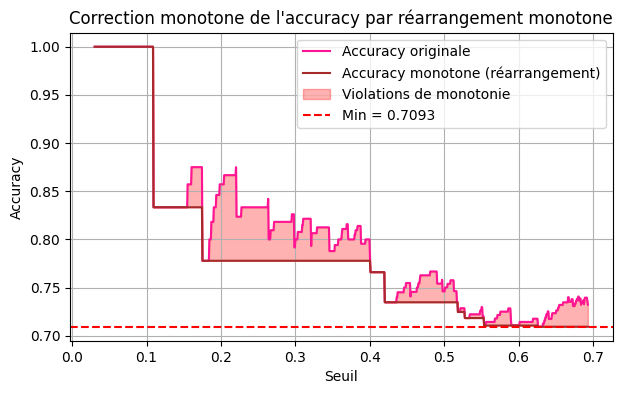

In [ ]:
rearranged_accuracies_pep = monotonic_rearrangement(accuracies_pep, thresholds_pep, accuracies_pep, color='deeppink')

In [ ]:
penalty_iso_pep = monotonicity_penalty(thresholds_pep, accuracies_pep, iso_accuracies_pep)
penalty_rearr_pep = monotonicity_penalty(thresholds_pep, accuracies_pep, rearranged_accuracies_pep)
print(f"Pénalité (aire des violations, isotone) : {penalty_iso_pep:.6f}")
print(f"Pénalité (aire des violations, réarrangement) : {penalty_rearr_pep:.6f}")

Pénalité (aire des violations, isotone) : 0.005355
Pénalité (aire des violations, réarrangement) : 0.013307


Seuil de PE_max

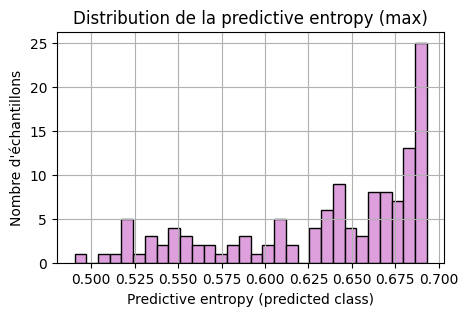

In [ ]:
entropies = metric_values['predictive_entropy_max']
if torch.is_tensor(entropies):
    entropies = entropies.cpu().numpy()

plt.figure(figsize=(5,3))
plt.hist(entropies, bins=30, color='plum', edgecolor='black')
plt.xlabel("Predictive entropy (predicted class)")
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution de la predictive entropy (max)")
plt.grid(True)
plt.show()

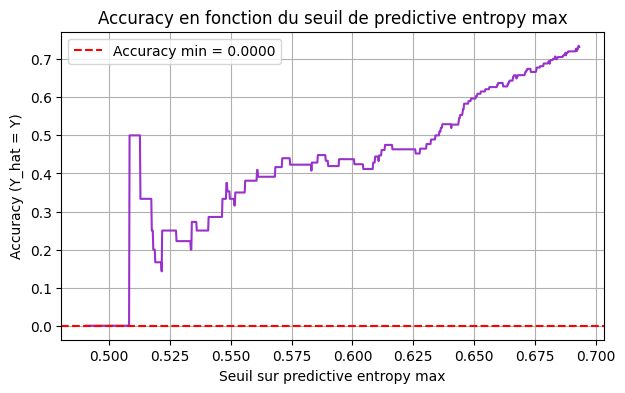

In [ ]:
thresholds_pem, accuracies_pem = accuracy_threshold(Y_hat, Y, metric_values['predictive_entropy_max'], metric_name="predictive entropy max", color="darkorchid")

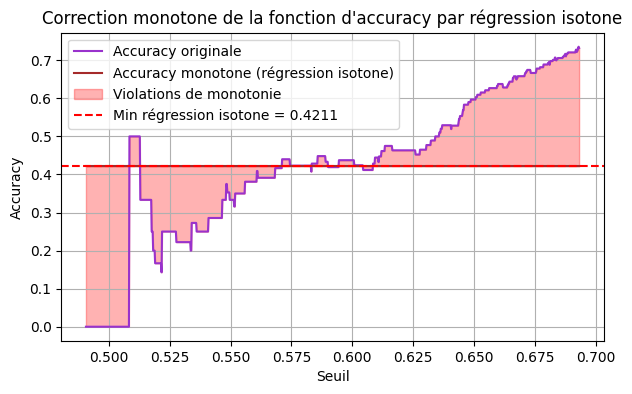

In [ ]:
iso_accuracies_pem = isotonic_regression(thresholds_pem, accuracies_pem, color='darkorchid')

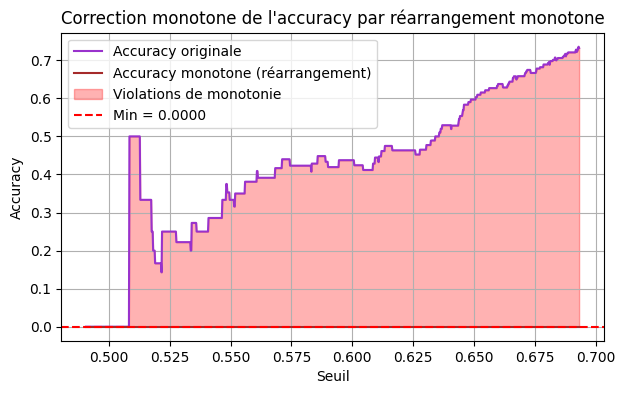

In [ ]:
rearranged_accuracies_pem = monotonic_rearrangement(accuracies_pem, thresholds_pem, accuracies_pem, color='darkorchid')

In [ ]:
penalty_iso_pem = monotonicity_penalty(thresholds_pem, accuracies_pem, iso_accuracies_pem)
penalty_rearr_pem = monotonicity_penalty(thresholds_pem, accuracies_pem, rearranged_accuracies_pem)
print(f"Pénalité (aire des violations, isotone) : {penalty_iso_pem:.6f}")
print(f"Pénalité (aire des violations, réarrangement) : {penalty_rearr_pem:.6f}")

Pénalité (aire des violations, isotone) : 0.028551
Pénalité (aire des violations, réarrangement) : 0.085318


In [ ]:
# Tableau récapitulatif des pénalités
penalties = {
    "variance_predicted": {
        "isotone": penalty_iso_vp,
        "rearrangement": penalty_rearr_vp
    },
    "variance_max": {
        "isotone": penalty_iso_vm,
        "rearrangement": penalty_rearr_vm
    },
    "predictive_entropy_predicted": {
        "isotone": penalty_iso_pep,
        "rearrangement": penalty_rearr_pep
    },
    "predictive_entropy_max": {
        "isotone": penalty_iso_pem,
        "rearrangement": penalty_rearr_pem
    }
}

df_penalties = pd.DataFrame(penalties).T
df_penalties.columns = ["Pénalité isotone", "Pénalité réarrangement"]
display(df_penalties)

,Pénalité isotone,Pénalité réarrangement
variance_predicted,0.001889,0.003889
variance_max,0.002533,0.019560
predictive_entropy_predicted,0.005355,0.013307
predictive_entropy_max,0.028551,0.085318


In [ ]:
metrics = ["variance_predicted", "variance_max", "predictive_entropy_predicted", "predictive_entropy_max"]
cols_to_show = []
# Ajouter les hyperparamètres du dico_layers
if len(df_manual_grid) > 0:
    for key in manual_grid_results[0]:
        if key not in ["mc_acc"] + [f"{m}_mean" for m in metrics] + [f"{m}_penalty_isotone" for m in metrics] + [f"{m}_penalty_rearrangement" for m in metrics]:
            cols_to_show.append(key)
cols_to_show.append("mc_acc")
for metric in metrics:
    mean_col = f"{metric}_mean"
    penalty_iso = f"{metric}_penalty_isotone"
    penalty_rearr = f"{metric}_penalty_rearrangement"
    if mean_col in df_manual_grid.columns:
        cols_to_show.append(mean_col)
    if penalty_iso in df_manual_grid.columns:
        cols_to_show.append(penalty_iso)
    if penalty_rearr in df_manual_grid.columns:
        cols_to_show.append(penalty_rearr)

display(df_manual_grid[cols_to_show])

,conv1,conv2,conv3,fc1,mc_acc
0,0.1,0.1,0.1,0.2,0.789062
1,0.5,NaN,NaN,0.5,0.640625
2,NaN,NaN,NaN,0.8,0.734375


Grid search sur dico_layers et stockage des résultats

In [ ]:
# Effectuer MC Dropout pour chaque modèle et stocker les résultats dans une liste
results = []

for i, (model, dico_layers, before) in enumerate([
    (model_1, "dico_layers_1", False),
    (model_2, "dico_layers_2", True),
    (model_3, "dico_layers_3", False)
]):
    X, Y = next(iter(testloader))
    X, Y = X.to(device), Y.to(device)
    probs, t = mc_predict_mean_probs(model, X, T=100, verbose=False)
    Y_hat = probs.argmax(1)
    acc = (Y_hat == Y).float().mean().item()
    results.append({
        "model": model,
        "dico_layers": dico_layers,
        "probs": probs,
        "t": t,
        "Y": Y,
        "Y_hat": Y_hat,
        "acc": acc
    })

# Pour chaque modèle, calculer les métriques et pénalités
for res in results:
    print(f"--- Résultats pour {res['dico_layers']} ---")
    outputs, mean_probs, metric_values, elapsed_forward, elapsed_metrics = generate_mc_outputs(
        res["model"], res["Y"], T=100, metrics=["variance_predicted", "variance_max", "predictive_entropy_predicted", "predictive_entropy_max"], labels=res["Y"], verbose=False
    )
    for metric in ["variance_predicted", "variance_max", "predictive_entropy_predicted", "predictive_entropy_max"]:
        thresholds, accuracies = accuracy_threshold(res["Y_hat"], res["Y"], metric_values[metric], metric_name=metric, num_thresholds=100, color="blue")
        iso_accuracies = isotonic_regression(thresholds, accuracies, color='blue')
        rearr_accuracies = monotonic_rearrangement(accuracies, thresholds, accuracies, color='blue')
        penalty_iso = monotonicity_penalty(thresholds, accuracies, iso_accuracies)
        penalty_rearr = monotonicity_penalty(thresholds, accuracies, rearr_accuracies)
        print(f"{metric}: penalty_isotone={penalty_iso:.6f}, penalty_rearrangement={penalty_rearr:.6f}")